In [1]:
%load_ext autoreload
%autoreload 2

# Amplitudes Validation

In [42]:
from few.amplitude.ampinterp1d import AmpInterp1PAT1R
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib.ticker as ticker

In [3]:
amp = AmpInterp1PAT1R()
modes = np.array([(l, m) for l in range(2, 6) for m in range(1, l + 1)])

In [4]:
with h5py.File("AmplitudesWaSABI1PAT1R.h5", "r") as trajectoryData:
    p, m1, m2, chi1, chi2, deltaM = np.array(trajectoryData["Grid"][:]).T
    nu = m1*m2/(m1+m2)**2.
    N_TESTS = len(p)

    Amp = {}
    for l,m in modes:
        Amp[l,m] = np.array(trajectoryData[f"l{l}m{m}"][:,0] + 1j * trajectoryData[f"l{l}m{m}"][:,1])

In [5]:
amp_values = {}
amp_FEW = {}
for l,m in modes:
    amp_values[l,m] = []
    for i in range(N_TESTS):
        amp_values[l,m].append(amp.get_amplitudes(0, p[i], 0.0, 1.0, nu=nu[i], chit = chi1[i], chit2 = chi2[i], delta_m1=deltaM[i], specific_modes =[(l,m,0,0)])[(l,m,0,0)][0])
    amp_FEW[l,m] = np.array(amp_values[l,m])

In [6]:
amp_RelativeError ={}
amp_AbsoluteError ={}
for l,m in modes:
    amp_RelativeError[l,m] = np.abs(1+amp_values[l,m]/Amp[l,m]*nu)#FIXME - sign and nu factor
    amp_AbsoluteError[l,m] = np.abs(Amp[l,m]/nu+amp_values[l,m])

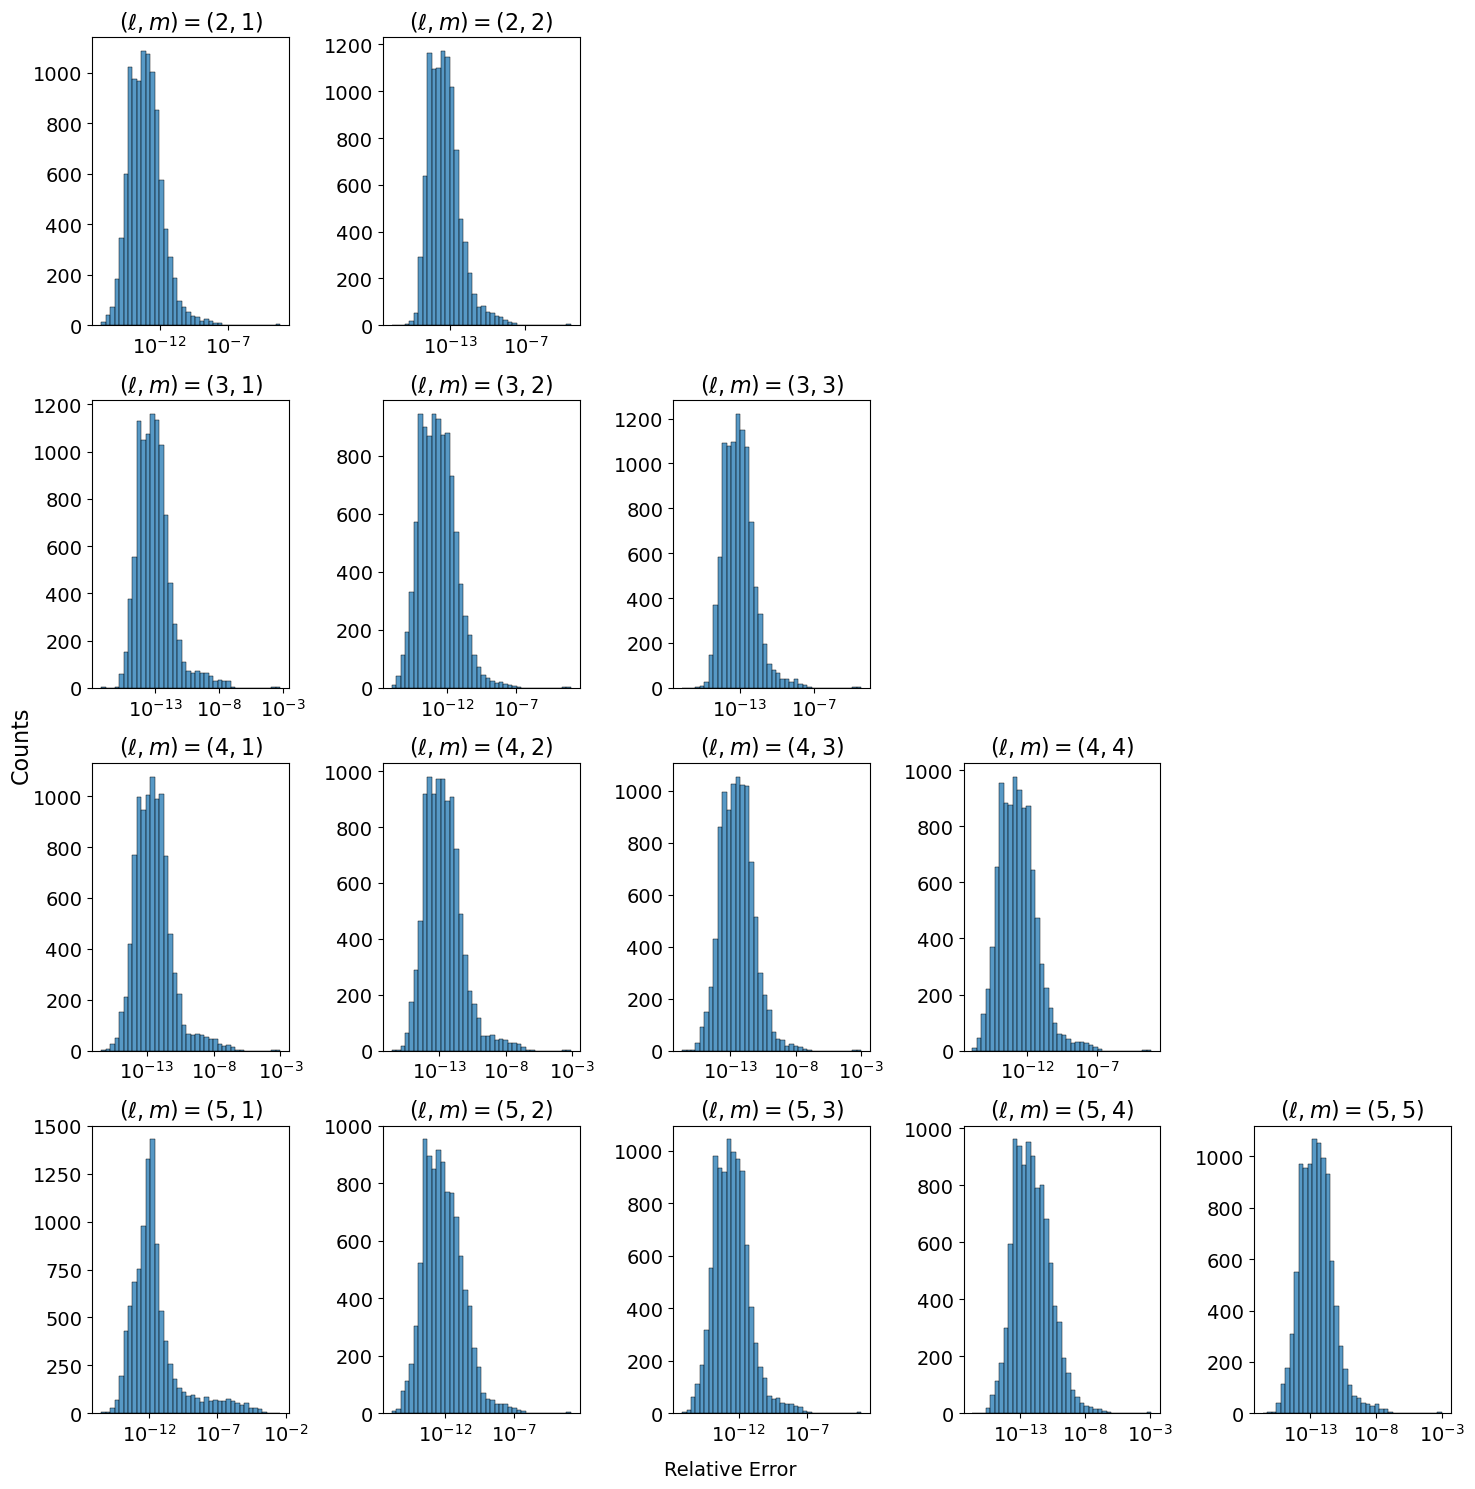

In [48]:
fig, axs = plt.subplots(4, 5, figsize=(15, 15), tight_layout=True)
fontsize = 16

for l,m in modes:
    sns.histplot(amp_RelativeError[l,m], bins=40, log_scale=True, ax=axs[l-2, m-1])
    axs[l-2, m-1].set_title(rf'$(\ell, m) =({l}, {m})$', fontsize=fontsize)
    axs[l-2, m-1].set_ylabel('')
    axs[l-2, m-1].tick_params(labelsize=fontsize-2)
    axs[l-2, m-1].xaxis.set_major_locator(ticker.LogLocator())
for ax in axs.flat:
    if not ax.has_data():
        ax.set_visible(False)
fig.supxlabel('Relative Error', fontsize=fontsize-2)
fig.supylabel('Counts', fontsize=fontsize)
plt.show()

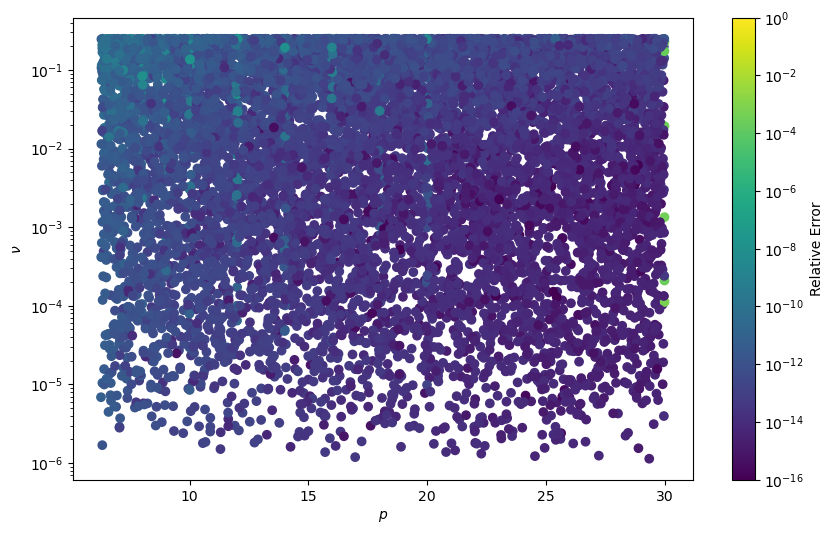

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(p, nu, c=amp_RelativeError[2,1], cmap='viridis', norm='log')
plt.clim(1e-16,1e-0)
plt.colorbar(label='Relative Error')
plt.xlabel(r'$p$')
plt.ylabel(r'$\nu$')
plt.yscale("log")

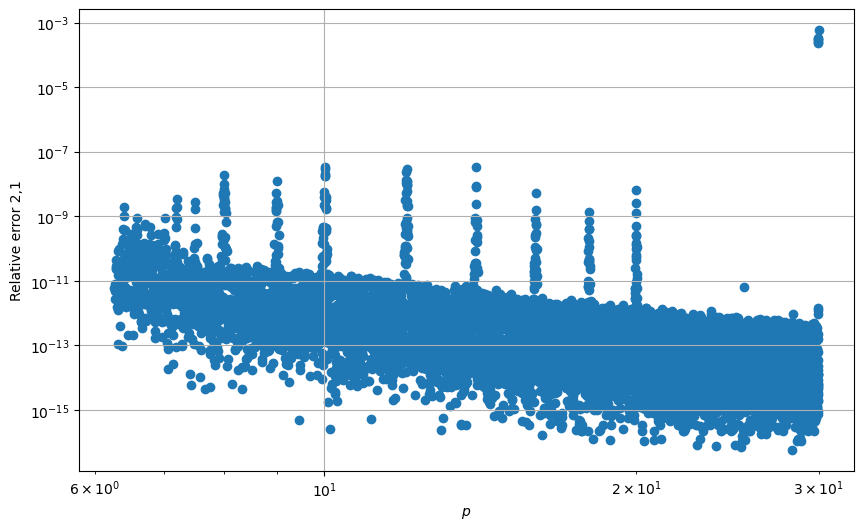

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(p, amp_RelativeError[2,1])
plt.yscale("log")
plt.xscale("log")
plt.xlabel(r'$p$')
plt.ylabel('Relative error 2,1')
plt.grid()
plt.show()